# HDT 2: Probabilidad, MLE y MAP

**Ciencia de Datos, Sección A** · Asignada: jueves 6 de agosto · **Entrega: jueves 13 de agosto, 23:59**

**Nombre:** _(escribir aquí)_

Completar las celdas marcadas con `# ¿Qué va aquí?`. Cada ejercicio incluye una verificación comentada: descomentar para comprobar el resultado. Antes de entregar: **Kernel → Restart & Run All** (un notebook que no corre de arriba a abajo pierde 0.5 pts).

AI: resolver sin AI. Si se usó para entender un concepto, anotarlo en la mini-bitácora del final.

## Setup

Dependencias: `pip install numpy pandas matplotlib requests`. El rango de fechas es fijo (1 de mayo al 31 de julio de 2026): todos trabajan con los mismos 92 días y las verificaciones son exactas.

In [7]:
import requests
import json
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

AZUL, ROJO, GRIS, LINEA = "#3A6EA5", "#B04A2E", "#75808E", "#E0E4EA"

def eje_limpio(ax):
    ax.grid(color=LINEA, lw=0.6, alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

URL = "https://archive-api.open-meteo.com/v1/archive"

## Parte A · Adquirir los datos (0.6 pt)

Clima observado de Ciudad de Guatemala (14.63, -90.51), del **2026-05-01** al **2026-07-31**, con las variables diarias `temperature_2m_max` y `precipitation_sum`, zona horaria `America/Guatemala`.

### Ejercicio 1 (0.15): descargar de la API

Armar el diccionario `params` con latitud, longitud, fechas, variables diarias (las dos en una sola cadena separada por coma) y zona horaria. Hacer el request y validar.

In [8]:
params = {
    "latitude": 14.63,
    "longitude": -90.51,
    "daily": "temperature_2m_max,precipitation_sum",
    "timezone": "America/Guatemala",
    "start_date": "2026-05-01",
    "end_date": "2026-07-31",
}

r = requests.get(URL, params=params, timeout=20)
print(r.status_code)
datos = r.json()

# Verificación (descomentar):
assert r.status_code == 200
assert list(datos["daily"].keys()) == ["time", "temperature_2m_max", "precipitation_sum"]

200


### Ejercicio 2 (0.15): JSON a DataFrame

Crear `clima` a partir de `datos["daily"]` y convertir la columna `time` a datetime.

In [9]:
clima = pd.DataFrame(datos["daily"])

# convertir time a datetime

clima["time"] = pd.to_datetime(clima["time"])
print(clima.head())

# Verificación (descomentar):
assert clima.shape == (92, 3)
assert clima.isna().sum().sum() == 0
assert str(clima["time"].dtype).startswith("datetime")

        time  temperature_2m_max  precipitation_sum
0 2026-05-01                29.6                0.0
1 2026-05-02                31.1                0.2
2 2026-05-03                28.2                0.9
3 2026-05-04                28.6                0.8
4 2026-05-05                30.9                1.6


### Ejercicio 3 (0.15): días con lluvia

(a) Columna booleana `llovio`: lluvia **mayor a 1.0 mm** (estricto). (b) `k` = días con lluvia y `n` = total de días. (c) El día con la lluvia máxima: fecha y milímetros.

In [ ]:
# ¿Qué va aquí?
# A
clima["lluvia > 1.0mm"] = clima["precipitation_sum"] > 1

# B
k = (clima["precipitation_sum"] > 0).sum()
n = (clima["time"]).count()
#print(n)
#print(k)
#print (f"llovio {n}")

#C
fila_max = clima.loc[clima["precipitation_sum"].idxmax()]
print(fila_max)
# Verificación (descomentar):
#assert int(clima["llovio"].sum()) == 51 and len(clima) == 92

71
time                  2026-06-22 00:00:00
temperature_2m_max                   23.6
precipitation_sum                    27.7
lluvia > 1.0mm                       True
Name: 52, dtype: object


### Ejercicio 4 (0.15): ficha de procedencia

Construir el diccionario `ficha` con las llaves `fuente`, `url`, `rango_fechas`, `fecha_descarga`, `filas` y `variables`. Guardarlo como `clima_procedencia.json` y guardar `clima` como `clima_gt.csv`.

In [11]:
ficha = {
    "fuente": "Open-Meteo API v1",
    "url": URL,
    "rango_fechas": ["2026-05-01" ,"2026-07-31"],
    "fecha_descarga": "2026-08-12",
    "filas": len(clima),
    "variables": list(clima.columns),
}
#assert ficha["filas"] == 92
# guardar ficha como clima_procedencia.json y clima como clima_gt.csv
with open("clima_procedencia.json", "w", encoding="utf-8") as f:
    json.dump(ficha, f, ensure_ascii=False, indent=2)

clima.to_csv("clima_gt.csv", index=False)
# Verificación (descomentar):
import os
assert os.path.exists("clima_procedencia.json") and os.path.exists("clima_gt.csv")
assert ficha["filas"] == 92

## Parte B · Estimar (1.2 pt)

Los datos ya están en memoria. Ahora la pregunta de la sesión 5: ¿qué parámetros hacen estos datos más plausibles?

### Ejercicio 5 (0.20): MLE de Bernoulli

Cada día es un ensayo Bernoulli: llueve o no. (a) `p_hat`, el MLE en una línea. (b) La función `log_lik` (vectorizada sobre `p`). (c) `p_grilla`: el argmax de `log_lik` sobre la grilla. Deben coincidir.

In [25]:
p_hat = k/n

def log_lik(p, k, n):
    return k * np.log(p) + (n - k) * np.log(1 - p)

grilla = np.linspace(0.001, 0.999, 999)
p_grilla = grilla[np.argmax(log_lik(grilla, k, n))]
print(p_hat, p_grilla)
# Verificación (descomentar):
assert abs(p_hat - k / n) < 1e-12
assert abs(p_grilla - p_hat) < 0.001

0.7717391304347826 0.772


### Ejercicio 6 (0.20): graficar la log-verosimilitud

Graficar `log_lik` sobre la grilla y marcar el máximo (línea vertical o anotación). El patrón está en el notebook de la sesión 5.

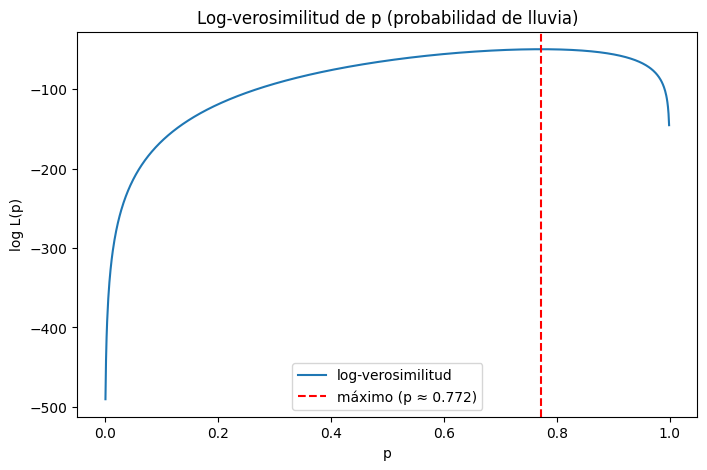

In [ ]:
L_grilla = log_lik(grilla, k, n) # ayuda de AI nunca habia usado Matplot

plt.figure(figsize=(8, 5))
plt.plot(grilla, L_grilla, label="log-verosimilitud")
plt.axvline(p_grilla, color="red", linestyle="--", label=f"máximo (p ≈ {p_grilla:.3f})")

plt.xlabel("p")
plt.ylabel("log L(p)")
plt.title("Log-verosimilitud de p (probabilidad de lluvia)")
plt.legend()
plt.show()

### Ejercicio 7 (0.20): MLE de la Normal

Sobre `temperature_2m_max`: (a) `mu_hat` sin usar `.mean()`. (b) `sigma2_hat`, el promedio de las desviaciones al cuadrado. Comparar con NumPy.

In [ ]:
temp = clima["temperature_2m_max"]

# a) mu_hat: el promedio, sin usar .mean()
mu_hat = ...

# b) sigma2_hat: promedio de (temp - mu_hat)**2
sigma2_hat = ...

# Verificación (descomentar):
# assert np.isclose(mu_hat, temp.mean())
# assert np.isclose(np.sqrt(sigma2_hat), temp.std(ddof=0))

### Ejercicio 8 (0.20): MAP con un prior equivocado

Prior Beta(2, 10): la creencia de alguien que piensa que en Guatemala casi no llueve (1 día de lluvia en 10 imaginarios). Implementar `map_beta` y comparar con el MLE usando los 92 días.

$$\hat{p}_{MAP} = \frac{k + \alpha - 1}{n + \alpha + \beta - 2}$$

In [ ]:
def map_beta(k, n, a=2, b=10):
    # ¿Qué va aquí?
    pass

# comparar MLE y MAP con los 92 días

# Verificación (descomentar):
# assert round(map_beta(k, n), 3) == 0.510

### Ejercicio 9 (0.20): el prior se diluye

Para cada `m` en `[7, 14, 30, 60, 92]`: con los **primeros** `m` días, calcular `k_m`, el MLE, el MAP y la diferencia absoluta. Guardar `(m, mle_m, map_m)` en `resultados` e imprimir la tabla.

In [ ]:
ns = [7, 14, 30, 60, 92]
resultados = []

for m in ns:
    #k_m = int(clima["llovio"][:m].sum())
    # ¿Qué va aquí? mle_m, map_m, agregar a resultados, imprimir
    pass

# Verificación (descomentar):
# difs = [abs(mle_m - map_m) for _, mle_m, map_m in resultados]
# assert round(difs[0], 2) == 0.19 and round(difs[-1], 2) == 0.04

KeyError: 'llovio'

### Ejercicio 10 (0.20): graficar la dilución

Con `resultados`: graficar MLE y MAP contra `m` (dos series con leyenda). El patrón está en el notebook de la sesión 5.

In [ ]:
# ¿Qué va aquí?

## Parte C · Criterio (0.2 pt)

### Ejercicio 11 (0.20)

El prior Beta(2,10) era objetivamente malo para época lluviosa. En 3-4 líneas, **citando los números del ejercicio 9**: ¿qué hicieron los datos con ese prior, a partir de cuántos días dejó de dominar, y qué implica esto para usar regularización (ridge/lasso) en modelos con pocos datos?

_(Responder editando esta celda)_

**Respuesta:** ...

## Mini-bitácora de AI (opcional, no penaliza)

Si se usó AI para entender algún concepto, anotar aquí qué se preguntó y qué se entendió. Si no se usó, escribir "No se usó".

en el ejercicio 4 se uso Ai, no para logica sino para hacerlo .json y un .csv que no entendia como hacerlo.
ejercicio 6, se uso AI para hacer la grafica
- ...